Loading data...
Sampling Rate: 250.08 Hz | Target Frequencies: [10, 3] Hz

--- Channel Rankings ---
Channel   SNR_dB
  EEG_2 8.296579
  EEG_7 7.773548
  EEG_6 5.521621
  EEG_3 5.501943
  EEG_8 5.423055
  EEG_5 5.234438
  EEG_1 5.189924
  EEG_4 3.851790

✅ Analysis complete! Best signal found on EEG_2. Graph saved to 'bin_session_analysis_zoomed.png'


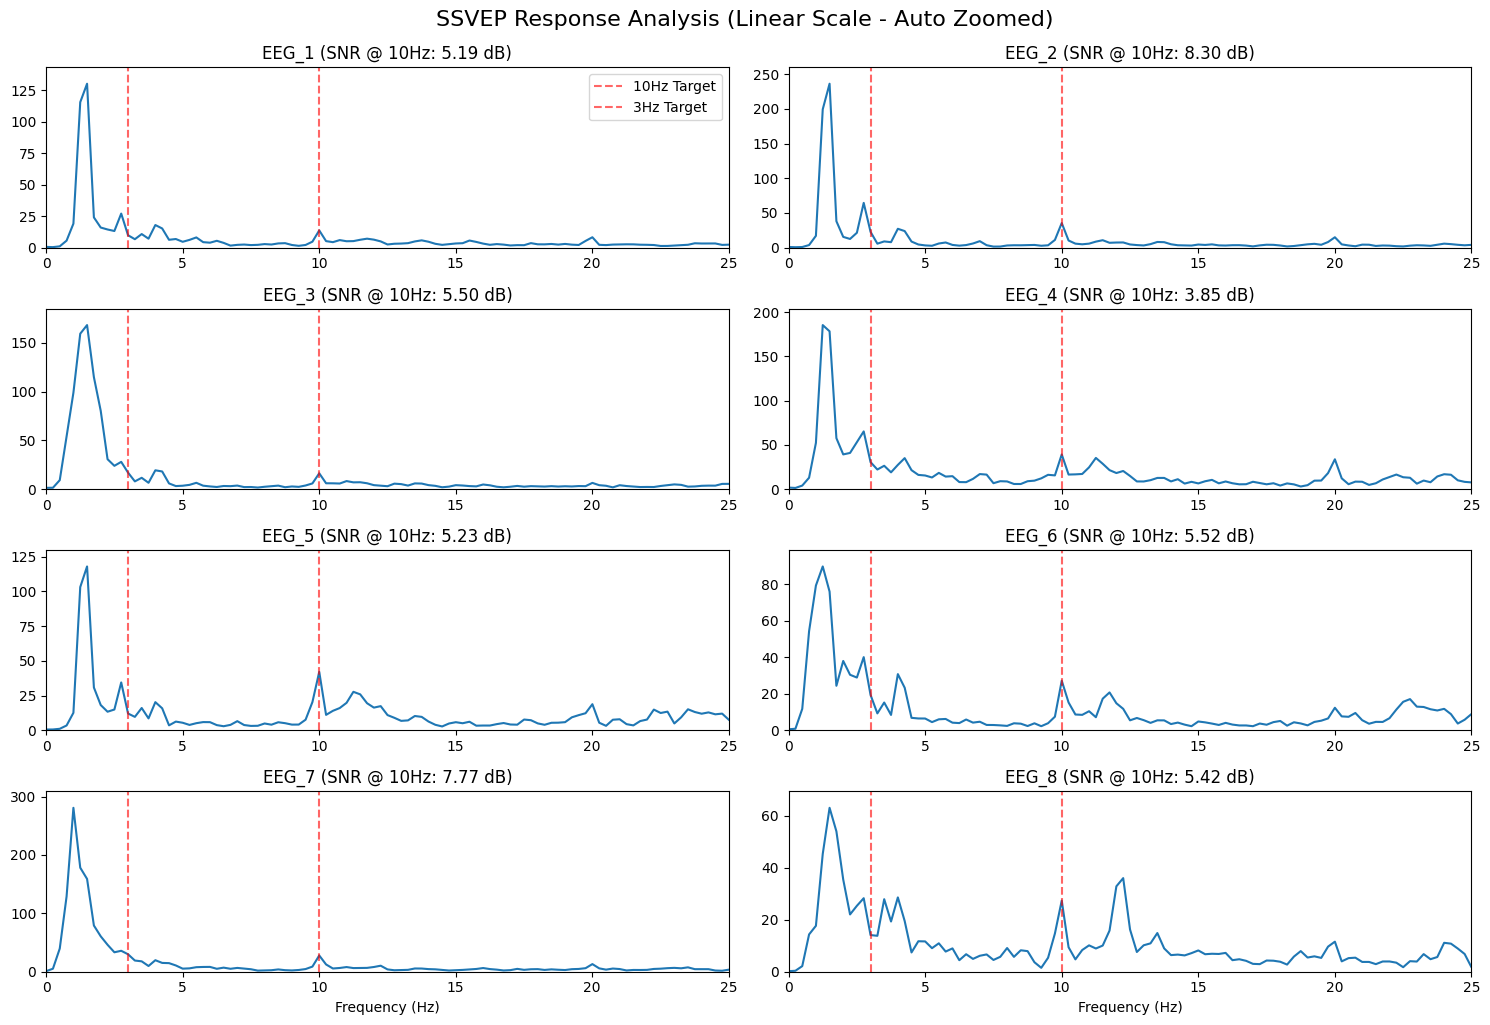

In [8]:
import struct
import numpy as np
import json
import pandas as pd
from scipy.signal import butter, lfilter, welch
import matplotlib.pyplot as plt

def process_bci_session(bin_file_path, json_file_path):
    print("Loading data...")
    # 1. Load the BIN file
    with open(bin_file_path, 'rb') as fh:
        # Unpack binary data (11 doubles per row) and skip the first 10 rows
        eeg_data_parsed = np.array(list(struct.iter_unpack('d'*11, fh.read())))[10:, :]

    # Extract columns based on your BCI format
    eeg_channels = eeg_data_parsed[:, 0:8]
    eeg_device_ts = eeg_data_parsed[:, 8] * 1e3
    eeg_record_ts = eeg_data_parsed[:, 10] 

    # 2. Load the JSON Interface Log
    with open(json_file_path, 'r') as f:
        log_data = json.load(f)

    # Get target frequencies from the caretaker's config
    targets = [opt['freq'] for opt in log_data['config']['options']]
    
    # 3. Synchronize using exact Unix Epoch Timestamps
    play_events = [e for e in log_data['events'] if e['type'] == 'play']
    pause_events = [e for e in log_data['events'] if e['type'] == 'pause']
    
    start_ts = play_events[-1]['timestamp']
    end_ts = pause_events[-1]['timestamp']
    
    # Mask to keep only the data recorded while the interface was flashing
    mask = (eeg_record_ts >= start_ts) & (eeg_record_ts <= end_ts)
    eeg_window = eeg_channels[mask]
    
    # Calculate Sampling Rate (fs)
    fs = 1000.0 / np.mean(np.diff(eeg_device_ts))
    print(f"Sampling Rate: {fs:.2f} Hz | Target Frequencies: {targets} Hz")

    # 4. Filter the Signal 
    def apply_bandpass(data, fs):
        nyq = 0.5 * fs
        b, a = butter(4, [1.0/nyq, (fs/2 - 1.0)/nyq], btype='band')
        return lfilter(b, a, data)

    # 5. Multi-Channel Frequency Analysis (PSD)
    channels = [f'EEG_{i+1}' for i in range(8)]
    results = []
    
    plt.figure(figsize=(15, 10))
    primary_target = targets[0] 
    display_max_f = max(targets) + 15 # The maximum frequency we want to show on the X-axis

    for i in range(8):
        # Center and Bandpass
        ch_data = eeg_window[:, i] - np.mean(eeg_window[:, i])
        clean_signal = apply_bandpass(ch_data, fs)
        
        # Calculate Power Spectral Density using Welch's method
        f, pxx = welch(clean_signal, fs, nperseg=int(fs*4))
        
        # Calculate Signal-to-Noise Ratio (SNR)
        idx_target = np.argmin(np.abs(f - primary_target))
        power_target = pxx[idx_target]
        
        mask_noise = (f >= (primary_target - 2)) & (f <= (primary_target + 2))
        mask_target = (f >= (primary_target - 0.5)) & (f <= (primary_target + 0.5))
        noise_power = np.mean(pxx[mask_noise & ~mask_target])
        
        snr = 10 * np.log10(power_target / noise_power) if noise_power > 0 else 0
        results.append({'Channel': channels[i], 'SNR_dB': snr})
        
        # --- PLOTTING LOGIC ---
        plt.subplot(4, 2, i+1)
        
        # Plot the actual linear data
        plt.plot(f, pxx) 
        
        # Draw target lines
        for t in targets:
            plt.axvline(t, color='red', linestyle='--', alpha=0.6, label=f'{t}Hz Target')
            
        # Dynamically scale the Y-axis to ONLY look at the peaks within our X-axis window
        valid_idx = (f >= 0) & (f <= display_max_f)
        local_max_power = np.max(pxx[valid_idx])
        
        plt.xlim(0, display_max_f)
        plt.ylim(0, local_max_power * 1.1) # Set Y-axis to the highest visible peak + 10% headroom
        
        plt.title(f"{channels[i]} (SNR @ {primary_target}Hz: {snr:.2f} dB)")
        
        if i == 0: 
            plt.legend()
        if i >= 6:
            plt.xlabel("Frequency (Hz)")

    plt.tight_layout()
    plt.suptitle("SSVEP Response Analysis (Linear Scale - Auto Zoomed)", y=1.02, fontsize=16)
    plt.savefig('bin_session_analysis_zoomed.png')
    
    # 6. Export Results
    rankings_df = pd.DataFrame(results).sort_values(by='SNR_dB', ascending=False)
    print("\n--- Channel Rankings ---")
    print(rankings_df.to_string(index=False))
    
    best_ch = rankings_df.iloc[0]['Channel']
    print(f"\n✅ Analysis complete! Best signal found on {best_ch}. Graph saved to 'bin_session_analysis_zoomed.png'")

if __name__ == "__main__":
    process_bci_session(
        bin_file_path='eeg_data_04072026_2125.bin',
        json_file_path='ssvep-log-1775611640328.json'
    )